In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
true_df = pd.read_csv(
    r"D:\MyDocuments_New\True_News.csv",
    encoding="latin1"
)

fake_df = pd.read_csv(
    r"D:\MyDocuments_New\Fake_News.csv",
    encoding="latin1"
)

C:\Users\Tanishq\AppData\Local\Temp\ipykernel_740\425817028.py:6: DtypeWarning: Columns (4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171) have mixed types. Specify dtype option on import or set low_memory=False.
  fake_df = pd.read_csv(


In [4]:
# Keep only required column
true_df = true_df[['text']]
fake_df = fake_df[['text']]

# Add labels
true_df['label'] = 'True'
fake_df['label'] = 'Fake'

In [5]:
df = pd.concat([true_df, fake_df], axis=0)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,text,label
0,President Obama began the new year of 2016 wit...,Fake
1,Chicago style politics buckle up America Barry...,Fake
2,ABOARD AIR FORCE ONE (Reuters) - President Bar...,True
3,WASHINGTON (Reuters) - A unit of the U.S. Trea...,True
4,Hollywood stars took to social media Wednesday...,Fake


In [6]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_df=0.7
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [8]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9896482635796973


In [9]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.952693677649154


In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

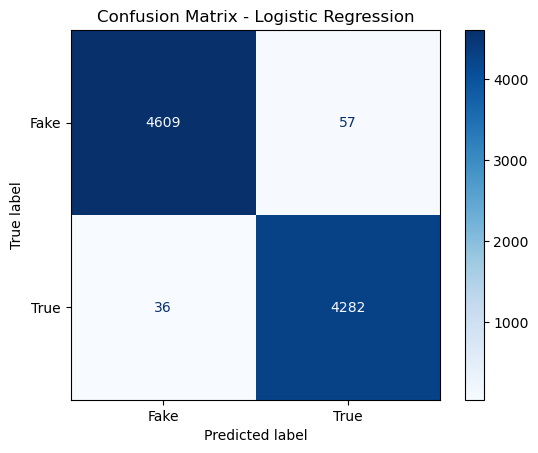

In [11]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=['Fake', 'True']
)

disp_lr.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [12]:
print("Classification Report - Logistic Regression")
print(classification_report(y_test, y_pred_lr))

Classification Report - Logistic Regression
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4666
        True       0.99      0.99      0.99      4318

    accuracy                           0.99      8984
   macro avg       0.99      0.99      0.99      8984
weighted avg       0.99      0.99      0.99      8984



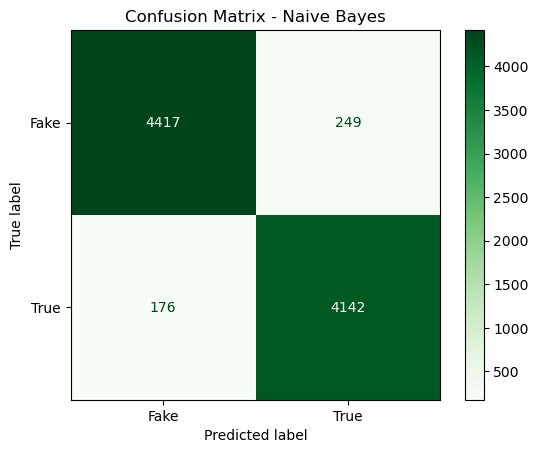

In [13]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

disp_nb = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=['Fake', 'True']
)

disp_nb.plot(cmap='Greens')
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

In [14]:
print("Classification Report - Naive Bayes")
print(classification_report(y_test, y_pred_nb))

Classification Report - Naive Bayes
              precision    recall  f1-score   support

        Fake       0.96      0.95      0.95      4666
        True       0.94      0.96      0.95      4318

    accuracy                           0.95      8984
   macro avg       0.95      0.95      0.95      8984
weighted avg       0.95      0.95      0.95      8984



In [15]:
sample_text = ["Breaking: Government secretly planning new tax on students"]

sample_vector = tfidf.transform(sample_text)

prediction = lr.predict(sample_vector)

print("Prediction:", prediction[0])

Prediction: Fake
